In [3]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "../data/processed/ssh_events.csv"

df = pd.read_csv(
    DATA_FILE,
    parse_dates=["timestamp"]
)

df.head()

,timestamp,hostname,pid,event_type,username,source_ip,source_port,invalid_user,success,event_count,message,line_number
0,2000-12-10 06:55:46,LabSZ,24200,breakin_warning,NaN,173.234.31.186,NaN,False,False,1,reverse mapping checking getaddrinfo for ns.ma...,1
1,2000-12-10 06:55:46,LabSZ,24200,invalid_user,webmaster,173.234.31.186,NaN,True,False,1,Invalid user webmaster from 173.234.31.186,2
2,2000-12-10 06:55:46,LabSZ,24200,other,NaN,NaN,NaN,False,False,1,input_userauth_request: invalid user webmaster...,3
3,2000-12-10 06:55:46,LabSZ,24200,other,NaN,NaN,NaN,False,False,1,pam_unix(sshd:auth): check pass; user unknown,4
4,2000-12-10 06:55:46,LabSZ,24200,auth_failure,NaN,173.234.31.186,NaN,False,False,1,pam_unix(sshd:auth): authentication failure; l...,5


In [4]:
print("Shape:", df.shape)

df.info()

Shape: (2000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     2000 non-null   datetime64[us]
 1   hostname      2000 non-null   str           
 2   pid           2000 non-null   int64         
 3   event_type    2000 non-null   str           
 4   username      1020 non-null   str           
 5   source_ip     1730 non-null   str           
 6   source_port   521 non-null    float64       
 7   invalid_user  2000 non-null   bool          
 8   success       2000 non-null   bool          
 9   event_count   2000 non-null   int64         
 10  message       2000 non-null   str           
 11  line_number   2000 non-null   int64         
dtypes: bool(2), datetime64[us](1), float64(1), int64(3), str(5)
memory usage: 160.3 KB


In [5]:
df.isna().sum()

timestamp          0
hostname           0
pid                0
event_type         0
username         980
source_ip        270
source_port     1479
invalid_user       0
success            0
event_count        0
message            0
line_number        0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())
print("Duration:", df["timestamp"].max() - df["timestamp"].min())

Start: 2000-12-10 06:55:46
End: 2000-12-10 11:04:45
Duration: 0 days 04:08:59


In [8]:
event_counts = (
    df["event_type"]
    .value_counts()
)

event_counts

event_type
failed_login            520
auth_failure            507
disconnect              468
other                   255
invalid_user            113
breakin_warning          85
connection_closed        34
no_identification        10
max_retries_exceeded      7
successful_login          1
Name: count, dtype: int64

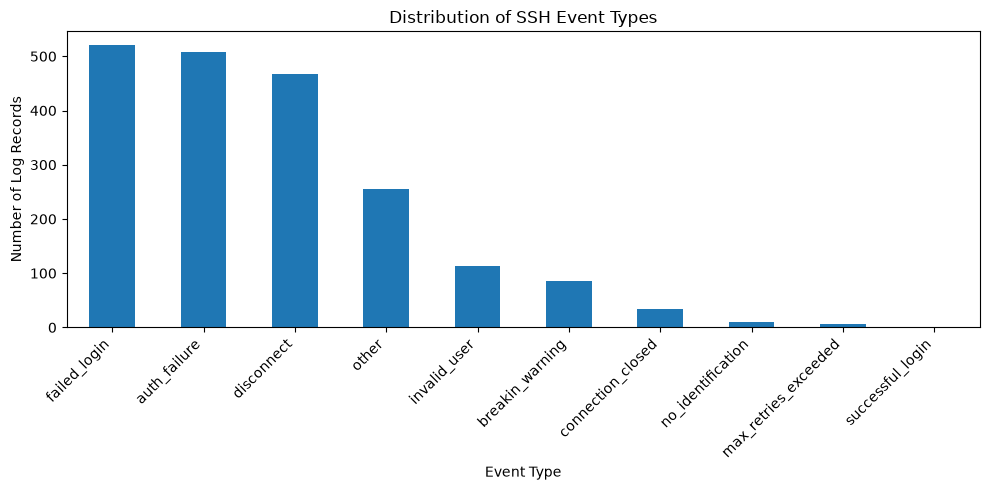

In [9]:
event_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Distribution of SSH Event Types")
plt.xlabel("Event Type")
plt.ylabel("Number of Log Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
print(
    "Unique source IPs:",
    df["source_ip"].nunique()
)

Unique source IPs: 30


In [11]:
top_ips = (
    df["source_ip"]
    .value_counts()
    .head(10)
)

top_ips

source_ip
183.62.140.253     867
187.141.143.180    349
103.99.0.122       172
112.95.230.3        80
5.188.10.180        51
185.190.58.151      42
123.235.32.19       22
52.80.34.196        15
60.2.12.12          15
103.207.39.212      12
Name: count, dtype: int64

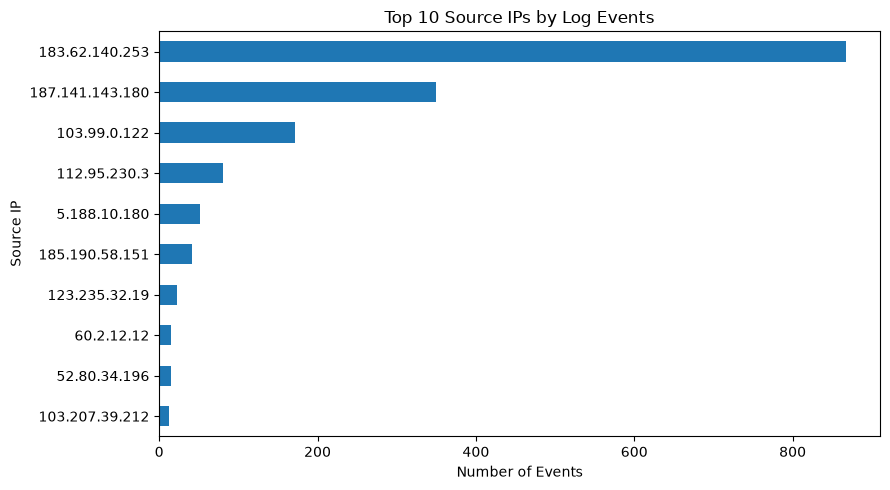

In [12]:
top_ips.sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Top 10 Source IPs by Log Events")
plt.xlabel("Number of Events")
plt.ylabel("Source IP")
plt.tight_layout()
plt.show()

In [13]:
failed = df[
    df["event_type"] == "failed_login"
].copy()

print("Failed-login rows:", len(failed))

print(
    "Actual failed-login occurrences:",
    failed["event_count"].sum()
)

Failed-login rows: 520
Actual failed-login occurrences: 528


In [14]:
failed_by_ip = (
    failed.groupby("source_ip")["event_count"]
    .sum()
    .sort_values(ascending=False)
)

failed_by_ip.head(10)

source_ip
183.62.140.253     286
187.141.143.180     80
103.99.0.122        46
112.95.230.3        26
5.188.10.180        18
185.190.58.151      17
123.235.32.19        7
106.5.5.195          6
119.4.203.64         6
5.36.59.76           6
Name: event_count, dtype: int64

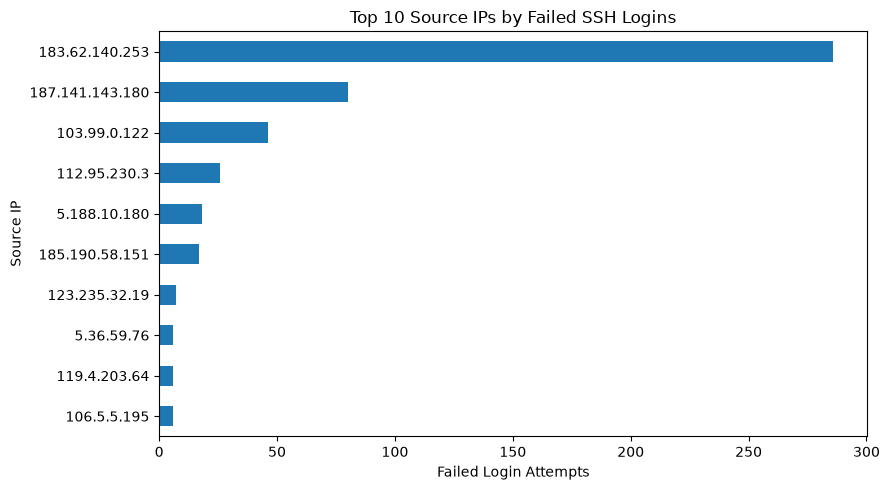

In [15]:
failed_by_ip.head(10).sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Top 10 Source IPs by Failed SSH Logins")
plt.xlabel("Failed Login Attempts")
plt.ylabel("Source IP")
plt.tight_layout()
plt.show()

In [16]:
top_users = (
    failed["username"]
    .value_counts()
    .head(15)
)

top_users

username
root         370
admin         44
support        6
oracle         6
uucp           5
test           5
user           4
inspur         3
1234           3
ftp            3
guest          3
matlab         3
git            3
webmaster      2
default        2
Name: count, dtype: int64

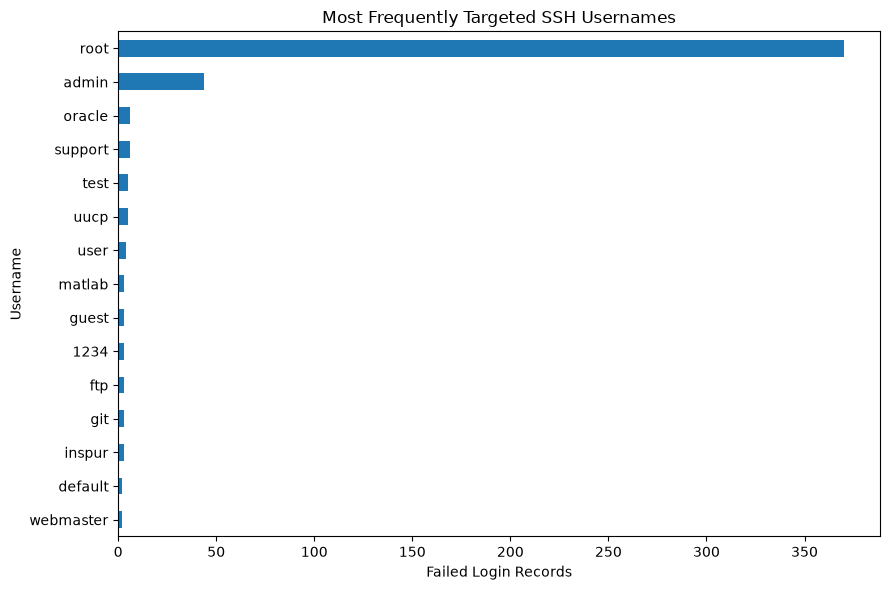

In [17]:
top_users.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Most Frequently Targeted SSH Usernames")
plt.xlabel("Failed Login Records")
plt.ylabel("Username")
plt.tight_layout()
plt.show()

In [18]:
unique_users_by_ip = (
    failed.groupby("source_ip")["username"]
    .nunique()
    .sort_values(ascending=False)
)

unique_users_by_ip.head(10)

source_ip
187.141.143.180    28
103.99.0.122       19
183.62.140.253     10
5.188.10.180        7
112.95.230.3        3
103.207.39.212      3
103.207.39.16       3
52.80.34.196        3
185.190.58.151      3
104.192.3.34        2
Name: username, dtype: int64

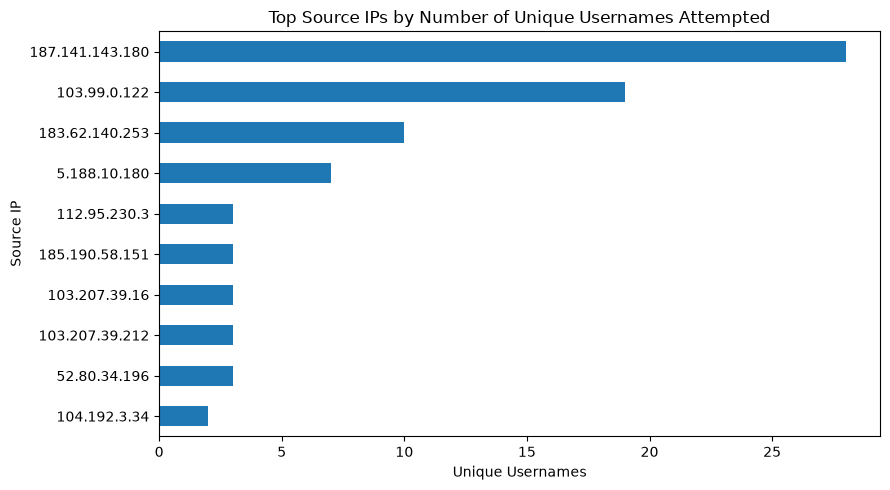

In [19]:
unique_users_by_ip.head(10).sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Top Source IPs by Number of Unique Usernames Attempted")
plt.xlabel("Unique Usernames")
plt.ylabel("Source IP")
plt.tight_layout()
plt.show()

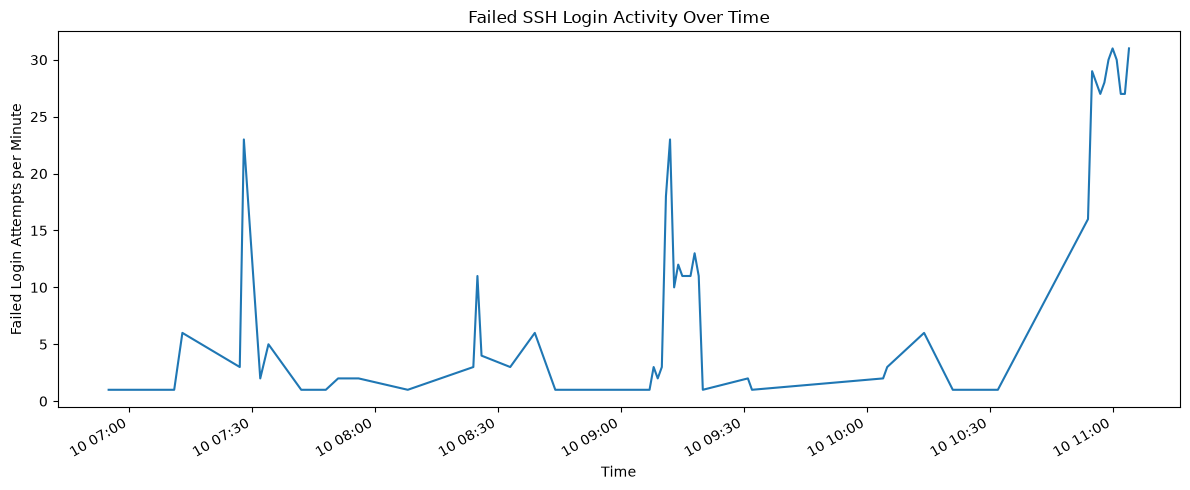

In [20]:
failed["minute"] = (
    failed["timestamp"]
    .dt.floor("min")
)

failures_over_time = (
    failed.groupby("minute")["event_count"]
    .sum()
)

failures_over_time.plot(
    figsize=(12, 5)
)

plt.title("Failed SSH Login Activity Over Time")
plt.xlabel("Time")
plt.ylabel("Failed Login Attempts per Minute")
plt.tight_layout()
plt.show()